In [13]:
import matplotlib.pyplot as plt
import pandas as pd

## Loading data

In [14]:
delivery_data = pd.read_csv('Food_Delivery_Time_Prediction.csv', sep=',')

delivery_data.head(5)

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


## Data preprocessing

### Removing unnecessery columns

Removing column *Order_ID*

In [15]:
delivery_data.drop(['Order_ID'], axis=1, inplace=True)
delivery_data.head(5)

,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


### Removing duplicate rows

In [16]:
print(f'DataFrame shape before removing duplicates: {delivery_data.shape}')

delivery_data.drop_duplicates(inplace=True)

print(f'DataFrame shape after removing duplicates: {delivery_data.shape}')

DataFrame shape before removing duplicates: (50000, 23)
DataFrame shape after removing duplicates: (50000, 23)


### Checking data types

In [17]:
print(f'Types before:\n\n{delivery_data.dtypes}')

delivery_data = delivery_data.astype({
    'Order_Date': 'datetime64[ns, UTC]',
})

print(f'Types before:\n\n{delivery_data.dtypes}')

Types before:

Order_Date                        str
Order_Hour                      int64
Day_of_Week                       str
Is_Weekend                      int64
Is_Festival                     int64
Weather                           str
Pickup_Zone                       str
Dropoff_Zone                      str
Vehicle_Type                      str
Rider_Experience_Years        float64
Rider_Rating                  float64
Restaurant_Rating             float64
Cuisine_Type                      str
Order_Items                     int64
Restaurant_Load                   str
Preparation_Time_Min            int64
Road_Distance_km              float64
Delivery_Distance_Category        str
Traffic_Level                     str
Number_of_Signals               int64
Average_Speed_kmph            float64
Delivery_Priority                 str
Time_taken_min                  int64
dtype: object
Types before:

Order_Date                    datetime64[ns, UTC]
Order_Hour                      

### Checking for missing values

In [18]:
delivery_data.isna().sum()

# delivery_data.dropna(inplace=True)

Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
Road_Distance_km              0
Delivery_Distance_Category    0
Traffic_Level                 0
Number_of_Signals             0
Average_Speed_kmph            0
Delivery_Priority             0
Time_taken_min                0
dtype: int64

### Checking for outliners

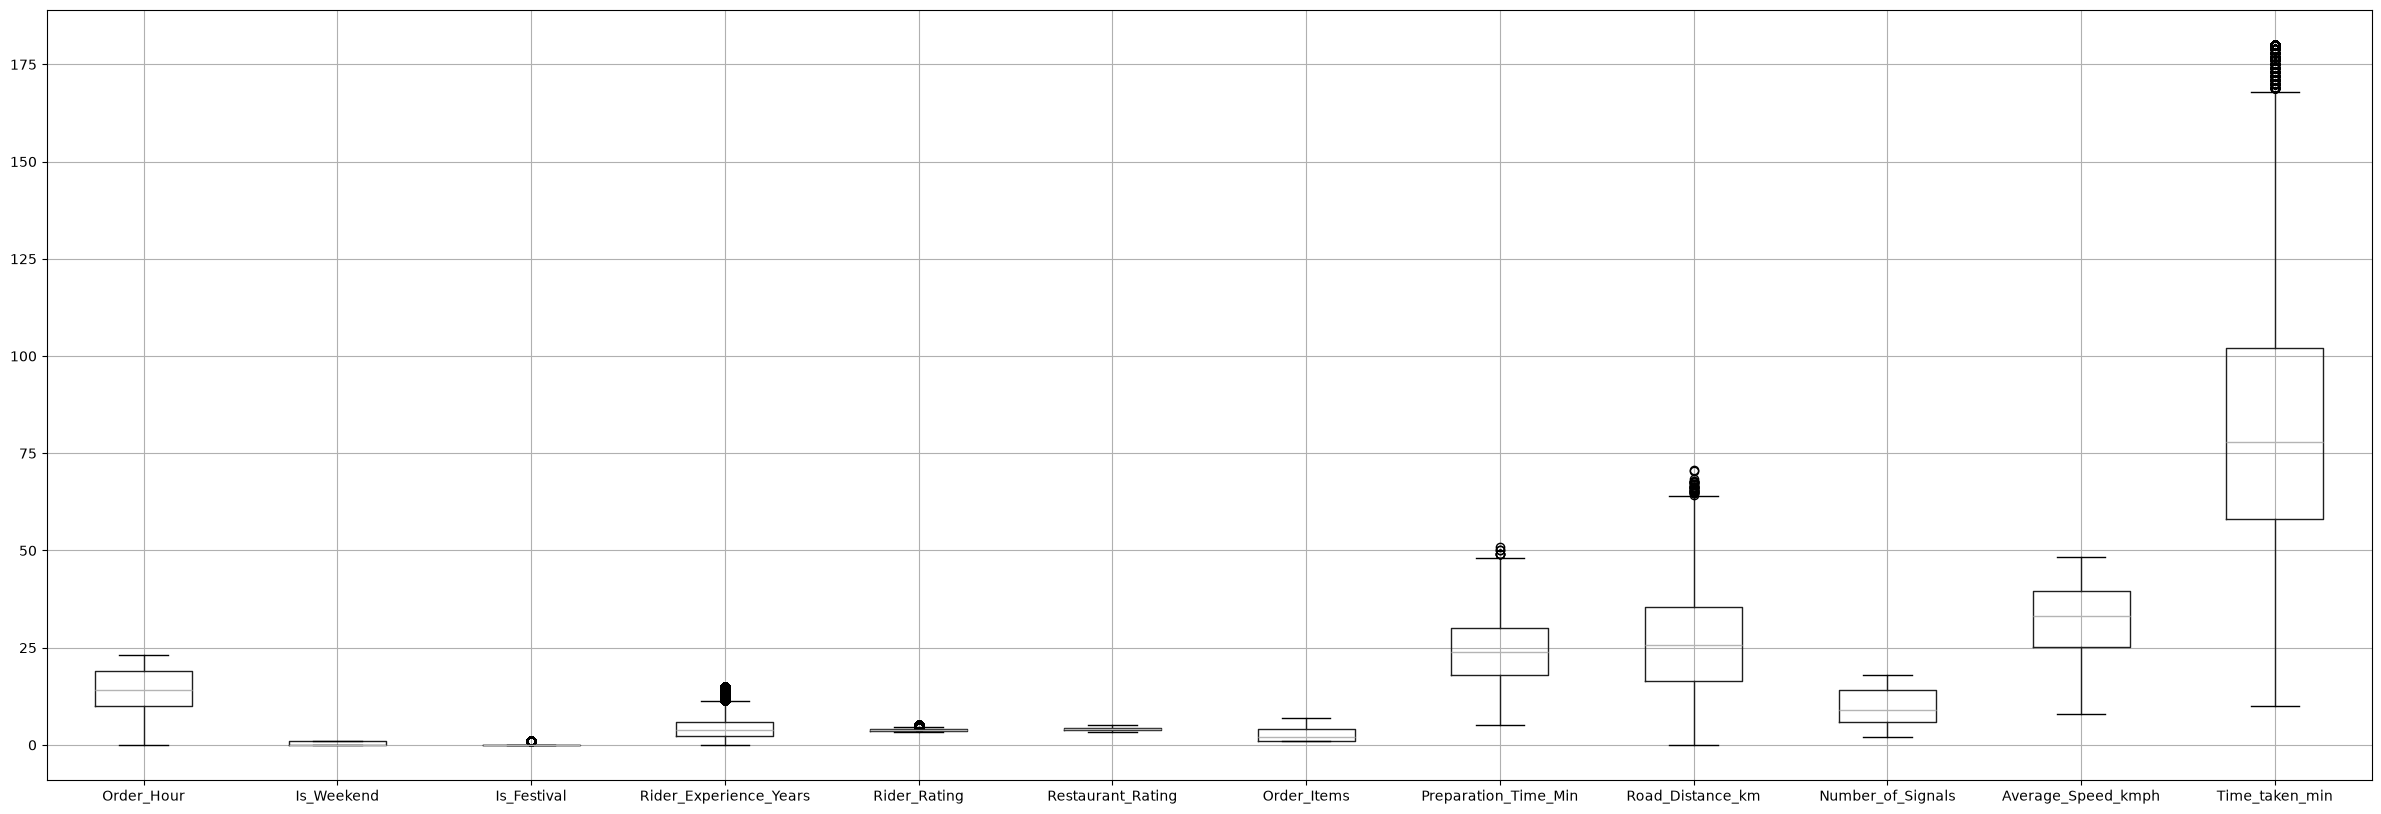

In [21]:
numerical = delivery_data.select_dtypes(include='number')

numerical.boxplot(figsize=(30, 10))
plt.show()